--- CLASS COUNTS ---
Churn
0    5174
1    1869
Name: count, dtype: int64


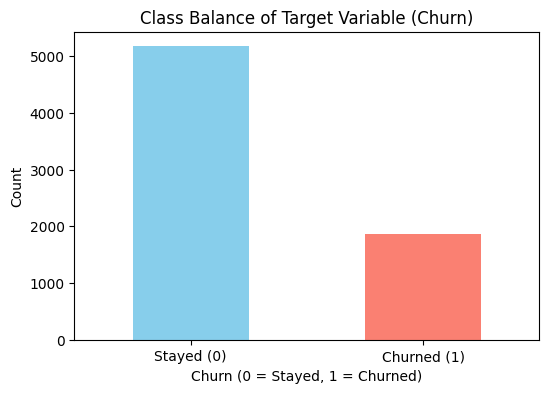


--- BASELINE MODEL (No Balancing) ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.44      0.52       373

    accuracy                           0.78      1409
   macro avg       0.73      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409


--- BALANCED MODEL (class_weight='balanced') ---
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.66      0.45      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the Telco Customer Churn dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 2. Preprocessing
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Check and Visualize Class Balance with a Bar Chart
class_counts = df['Churn'].value_counts()
print("--- CLASS COUNTS ---")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Balance of Target Variable (Churn)')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Stayed (0)', 'Churned (1)'], rotation=0)
plt.show()

# Prepare features and target
X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Baseline Model (Without handling imbalance)
print("\n--- BASELINE MODEL (No Balancing) ---")
base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)
base_preds = base_model.predict(X_test)
print(classification_report(y_test, base_preds))

# 5. Train Balanced Model (Using class_weight='balanced')
print("\n--- BALANCED MODEL (class_weight='balanced') ---")
balanced_model = RandomForestClassifier(class_weight='balanced', random_state=42)
balanced_model.fit(X_train, y_train)
balanced_preds = balanced_model.predict(X_test)
print(classification_report(y_test, balanced_preds))

**Why Accuracy is a Misleading Metric Here:**

In our dataset, roughly 73% of the customers do not churn, while only 27% do. If we built a lazy model that simply guessed "0" (Stayed) for every single customer, it would achieve a 73% overall accuracy score on paper. However, that model would completely fail at its actual business objective: identifying the customers who are about to leave so we can save them. Accuracy hides the model's total inability to predict the minority class, which is why we must rely instead on Recall, Precision, and F1-score to evaluate performance accurately.